# Load and Visualize Radar Vectors Dataset

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import torch

### Load Dataset Files

Load the NPZ file which contains: metadata.npy, y_timestamps.npy, X.npy, and Y.npy.

In [17]:
DATASET_PATH = Path('../data/dataset_radar_vetores_5in_5out.npz')   

In [18]:
def load_radar_dataset(npz_file_path):
    data = np.load(npz_file_path, allow_pickle=True)
    
    dataset = {
        'X': data['X'],
        'Y': data['Y'],
        'metadata': data['metadata'],
        'y_timestamps': data['y_timestamps']
    }
    
    return dataset

In [19]:
dataset = load_radar_dataset(DATASET_PATH)

print(f"Dataset loaded successfully from: {DATASET_PATH}")
print(f"Available keys: {list(dataset.keys())}")

Dataset loaded successfully from: ../data/dataset_radar_vetores_5in_5out.npz
Available keys: ['X', 'Y', 'metadata', 'y_timestamps']


### Explore Dataset Structure

Display the shapes and basic information about each loaded array to understand the dataset structure.

In [20]:
print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

print("\n1. Input Data (X):")
print(f"   Shape: {dataset['X'].shape}")
print(f"   Data type: {dataset['X'].dtype}")

print("\n2. Output Data (Y):")
print(f"   Shape: {dataset['Y'].shape}")
print(f"   Data type: {dataset['Y'].dtype}")

print("\n3. Metadata:")
print(f"   Shape: {dataset['metadata'].shape}")
print(f"   Data type: {dataset['metadata'].dtype}")
if dataset['metadata'].ndim > 0 and len(dataset['metadata']) > 0:
    print(f"   First entry: {dataset['metadata'][0]}")
elif dataset['metadata'].ndim == 0:
    print(f"   Value: {dataset['metadata']}")

print("\n4. Y Timestamps:")
print(f"   Shape: {dataset['y_timestamps'].shape}")
print(f"   Data type: {dataset['y_timestamps'].dtype}")
if dataset['y_timestamps'].ndim > 0 and len(dataset['y_timestamps']) > 0:
    print(f"   First timestamp: {dataset['y_timestamps'][0]}")
elif dataset['y_timestamps'].ndim == 0:
    print(f"   Value: {dataset['y_timestamps']}")

print("\n" + "=" * 60)

DATASET STRUCTURE

1. Input Data (X):
   Shape: (1407, 5, 256, 256, 3)
   Data type: uint8

2. Output Data (Y):
   Shape: (1407, 5, 256, 256, 3)
   Data type: uint8

3. Metadata:
   Shape: ()
   Data type: object
   Value: {'start_date': '2024-03-06', 'end_date': '2024-03-07', 'time_step_minutes': 2, 'height': 256, 'width': 256, 't_in': 5, 't_out': 5, 'channels': 3, 'mode': 'rgb'}

4. Y Timestamps:
   Shape: (1407, 5)
   Data type: object
   First timestamp: ['2024-03-06T00:09:00' '2024-03-06T00:11:00' '2024-03-06T00:13:00'
 '2024-03-06T00:15:00' '2024-03-06T00:17:00']



# Testing STConvS2S plot image 

Below is the code used in STConvS2S `util.py` and the new method check_flip added in `dataset.py` to check if it is necessary to flip the data because the image has a different coordinate system.

In [21]:
def check_flip(dataset):
        """
        Check if dataset has geographic coordinates (lat/lon).
        Works with xarray.Dataset objects that have a .coords attribute.
        Returns False for numpy arrays or objects without coordinates.
        """
        # Check if the object has coordinates attribute (xarray.Dataset)
        if not hasattr(dataset, 'coords'):
            print("Dataset is not an xarray object or doesn't have coordinates.")
            return False
        
        lat_coord, lon_coord = None, None
        
        for coord_name in dataset.coords:
            coord_lower = coord_name.lower()
            
            if 'lat' in coord_lower:
                lat_coord = coord_name
            elif 'lon' in coord_lower:
                lon_coord = coord_name
        
        if lat_coord is not None and lon_coord is not None:
            print(f"Latitude coordinate: {lat_coord}, Longitude coordinate: {lon_coord}")
            return True
        
        print("Latitude and/or Longitude coordinates not found in dataset.")
        return False

In [22]:
should_flip = check_flip(dataset['X'])

Dataset is not an xarray object or doesn't have coordinates.


### Dataset shape for STConvS2S

samplae x time x L x H x channel --> sample x channel x time x L x H

In [23]:
X = np.transpose(dataset['X'], (0, 4, 1, 2, 3))
X = torch.from_numpy(X)
X.shape

torch.Size([1407, 3, 5, 256, 256])

In [24]:
def create_image_plot(tensor, ax, i, j, index, step, ax_input=False):
    cmap = 'viridis'
    tensor = np.transpose(tensor, (0, 2, 3, 4, 1))
    tensor_numpy = tensor[0,index,:,:,:].squeeze().cpu().numpy()
    origin = 'lower' if should_flip else 'upper'
        
    if step == 5 or ax_input:
        ax[j].imshow(tensor_numpy, cmap=cmap, origin=origin)
        ax[j].get_xaxis().set_visible(False)
        ax[j].get_yaxis().set_visible(False)
    else:
        ax[i][j].imshow(tensor_numpy, cmap=cmap, origin=origin)
        ax[i][j].get_xaxis().set_visible(False)
        ax[i][j].get_yaxis().set_visible(False)        
    return ax

def save_examples(inputs):
        step = 5
        input_seq_length = inputs.shape[2]
        row = step // input_seq_length
        fig_input, ax_input = plt.subplots(nrows=1, ncols=input_seq_length)
        count = 0
        for i in range(row):
            for j in range(input_seq_length):
                if step == 5:
                    ax_input[j] = create_image_plot(inputs, ax_input, i, j, count+j, step)  
                else:
                    if i == 0:
                        ax_input[j] = create_image_plot(inputs, ax_input, i, j, count+j, step, ax_input=True)
            count+=5

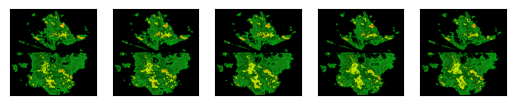

In [25]:
save_examples(X)